**ISD-1020 · Master ISD (apprenticeship) · Université Paris-Saclay**

**Before any edit:** `File → Save a copy in Drive`.
Work only on **your** copy.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sklearn, torch

print("sklearn", sklearn.__version__, "| torch", torch.__version__)

sklearn 1.6.1 | torch 2.11.0+cpu


# Course helpers — skip this

This cell is **not** an exercise: it downloads the plotting helpers and dataset
loaders if they are not already next to the notebook. You do not need to read
it. Continue below.


In [3]:
# Environment setup (when run outside the repository, e.g. Google Colab)
import sys
import urllib.request
from pathlib import Path

_RAW_BASE = "https://raw.githubusercontent.com/stephane-rivaud/M2-ISD-ML-DL/main"

for _start in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_start / "pyproject.toml").is_file() and (_start / "common").is_dir():
        if str(_start) not in sys.path:
            sys.path.insert(0, str(_start))
        break

try:
    for module_path in ("common/__init__.py", "common/plots.py", "data/fetch.py"):
        local_file = Path(module_path)
        if local_file.is_file() or any(
            (Path(p) / module_path).is_file() for p in sys.path if p
        ):
            continue
        local_file.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(f"{_RAW_BASE}/{module_path}", local_file)
except Exception:
    print(
        "Could not download the course helpers. Clone or download this repository so common/ and data/ sit next to this notebook."
    )


# First contact — who will churn?

ISD-1020 · Monday 14 September 2026 · workshop 15:00–16:40 (100 min).

Thread of the module: **1. Problem · 2. Data · 3. Baseline · 4. Model · 5. Ablation ·
6. Error analysis → Recommendation**.
Today we go as far as error analysis; the protocol is at the end.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from common.plots import plot_confusion, plot_pr_curve
from data.fetch import load_telco

RANDOM_STATE = 0

## The problem — ⏱ ~8 min

A telecom operator wants to know **who will churn** next month
(`Churn` = `"Yes"` / `"No"`). Recruiting a subscriber costs distinctly more
than retaining one: a retention offer is targeted at likely leavers.

The costly error is the **false negative** (a customer leaves, the model
said nothing). Catching leavers (recall on `"Yes"`) matters more
than matching the overall rate of correct answers (accuracy).

In pairs: what concrete decision would a customer-service team take with
a list of churn scores? (30 s, spoken within the group)

## Data — ⏱ ~12 min

IBM Telco Customer Churn: one customer per row, services and a
contract. Local copy if it is there, otherwise IBM's public CSV.

In [5]:
df = load_telco()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

telco: loaded from the course repository
shape: (7043, 21)
columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [30]:
df.loc[(df["tenure"] == 72) & (df["Churn"] == 'Yes'), ["tenure", "MonthlyCharges", "Churn"]]

,tenure,MonthlyCharges,Churn
3111,72,103.40,Yes
3439,72,104.15,Yes
3890,72,109.25,Yes
4513,72,92.45,Yes
4610,72,117.80,Yes
6424,72,54.20,Yes


In [7]:
print("Missing values:")
print(df.isna().sum())
print()
print("The 11 empty `TotalCharges` (tenure = 0, customers too recent):")
df.loc[df["TotalCharges"].isna(), ["tenure", "MonthlyCharges", "Churn"]]

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

The 11 empty `TotalCharges` (tenure = 0, customers too recent):


,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


**Exercise.** Compute the **churn rate**: the share of rows with
`Churn == "Yes"`. Also print `value_counts(normalize=True)`.
You should find about **26.5%** `"Yes"` (hence 73.5% `"No"`).

In [8]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


## Baseline — ⏱ ~12 min

Before any model: **always predict the majority class** (`"No"`).
That is the honest floor, not a "deliberately weak" model.

**Exercise.** Compute the accuracy of "always `"No"`" on the whole `df`,
then the **recall** (`recall_score`) of class `"Yes"`
(`pos_label="Yes"`). Keep these two numbers in view.

In [9]:
y_pred = np.full(7043, "No")
acc = accuracy_score(df['Churn'], y_pred)

rec = recall_score(df['Churn'], y_pred, pos_label="Yes")
print(f'accuracy = {acc}, recall = {rec}')


accuracy = 0.7346301292063041, recall = 0.0


**Accuracy lies.** ~73.5% correct answers **without ever catching
a leaver**. A model that "gets 80% accuracy" may be only a
tiny step above "always no". From now on we will read
**recall** and the **confusion matrix**.

## First model — ⏱ ~15 min

Logistic regression, preceded by preprocessing in a `Pipeline`
(so as not to fit the scaler on the test set: no leakage).

- `customerID`: identifier, we **drop** it.
- Missing `TotalCharges`: set it to **0** (tenure 0: nothing billed).
- numeric → `StandardScaler`; categorical → `OneHotEncoder`.
- **stratified** 80/20 split, `random_state=RANDOM_STATE` (reproducible).

The `Pipeline` is already built. Your turn: the split, then `fit`.

In [10]:
X = df.drop(columns=["customerID", "Churn"]).copy()
X["TotalCharges"] = X["TotalCharges"].fillna(0.0)
y = df["Churn"].copy()

NUMERIC = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAL = [c for c in X.columns if c not in NUMERIC]

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), NUMERIC),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL,
        ),
    ]
)
pipe = Pipeline(
    [
        ("prep", preprocessor),
        (
            "clf",
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        ),
    ]
)
print("numeric:", NUMERIC)
print("categorical:", CATEGORICAL)

numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Exercise.** Split `X`, `y` into train/test: `test_size=0.2`,
`stratify=y`, `random_state=RANDOM_STATE`. Expected names:
`X_train`, `X_test`, `y_train`, `y_test`.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

In [12]:
print("train:", X_train.shape, "test:", X_test.shape)
print("churn rate train:", (y_train == "Yes").mean().round(3))
print("churn rate test: ", (y_test == "Yes").mean().round(3))

train: (5634, 19) test: (1409, 19)
churn rate train: 0.265
churn rate test:  0.265


**Exercise.** Fit the pipeline: `pipe.fit(X_train, y_train)`.

In [13]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('clf', LogisticRegression(max_iter=1000, random_state=0))])

model accuracy   = 0.801
majority on test = 0.735


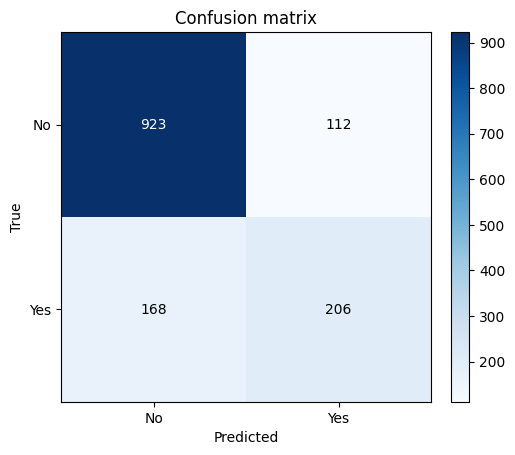

In [14]:
y_pred = pipe.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)
print(f"model accuracy   = {model_accuracy:.3f}")
print(f"majority on test = {accuracy_score(y_test, ['No'] * len(y_test)):.3f}")
plot_confusion(y_test, y_pred, labels=["No", "Yes"])
plt.show()

Checkpoint (⏱ ~5 min, Solal circulating): every group has a fitted
`pipe` and a confusion matrix. The cell **true `"Yes"`, predicted
`"No"`** (bottom left) is the pile of missed leavers.

**Exercise.** Compute recall of class `"Yes"` on the test set
(`recall_score`, `pos_label="Yes"`). Compare it to 0 (baseline) and to
the model's accuracy of ~0.80.

In [ ]:
# To complete
recall_score(y_test, y_pred, pos_label="Yes")

0.5508021390374331

**Take-away for the oral exam.** Baseline: ~73.5% accuracy, **0**
recall. Logistic: ~80% accuracy (looks like little) but ~55%
recall: we start catching leavers. **Read recall and the
matrix, not accuracy.**

## Reading the errors — ⏱ ~15 min

Five **false negatives**: true `"Yes"`, predicted `"No"`. These are
not five random rows: they are five leavers **on a long contract**
(one year or two years), sorted by `tenure` descending.

Look at **`Contract`**, **`tenure`** and **`MonthlyCharges`**. What
do they share? (commitment contract, high seniority, often a high
bill — customers one believes to be "stable".)

In [15]:
fn_mask = (y_test == "Yes") & (y_pred == "No")
false_negatives = X_test.loc[fn_mask]
fn_show_cols = [
    "Contract",
    "tenure",
    "MonthlyCharges",
    "InternetService",
    "PaymentMethod",
]
five_fn = (
    false_negatives.loc[false_negatives["Contract"] != "Month-to-month"]
    .sort_values("tenure", ascending=False)
    .head(5)
)
five_fn[fn_show_cols]

,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod
3040,Two year,71,108.60,Fiber optic,Credit card (automatic)
6945,Two year,70,98.30,Fiber optic,Bank transfer (automatic)
5841,One year,70,45.25,DSL,Electronic check
5258,One year,69,104.70,Fiber optic,Bank transfer (automatic)
5581,Two year,68,113.15,Fiber optic,Electronic check


**Exercise.** On **all** false negatives of the test set, then on the
**true positives** (`y_test == "Yes"` and `y_pred == "Yes"`), print
`value_counts()` of `Contract`. Are the true positives the same
contract type as these five rows?

In [35]:
five_fn['Contract'].value_counts()

,count
Contract,
Two year,3
One year,2


In [43]:
tp_mask = (y_test == "Yes") & (y_pred == "Yes")
true_positives = X_test.loc[tp_mask]
tp_show_cols = [
    "Contract",
    "tenure",
    "MonthlyCharges",
    "InternetService",
    "PaymentMethod",
]
five_tp = (
    true_positives.loc[true_positives["Contract"] != "Month-to-month"]
    .sort_values("tenure", ascending=False)
)
five_tp[tp_show_cols]

,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod


In [44]:
five_tp['Contract'].value_counts()

,count
Contract,


Business reading: on this split, **no** true positive has a one-year
or two-year contract — the model only "sees" churn among
month-to-month. The five rows above (long tenure, high bill)
are exactly the expensive kind of leaver: they were believed retained by
the contract.

## Fast track — ⏱ ~15 min (optional)

For those who have already done ML: same split, a
`HistGradientBoostingClassifier`, the **PR-AUC** (better than accuracy
on an imbalanced problem) and permutation importance.
`n_repeats=5` (not 30) to stay within the CPU budget.

HGB accuracy = 0.796
HGB recall   = 0.527
PR-AUC       = 0.649  (no-skill ≈ 0.265)


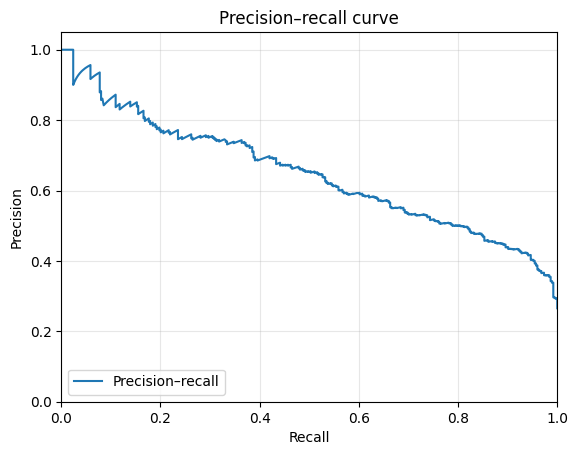

In [45]:
# ⚡ Fast track (optional) — for those who have already done ML
hgb = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    ("num", StandardScaler(), NUMERIC),
                    (
                        "cat",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        CATEGORICAL,
                    ),
                ]
            ),
        ),
        (
            "clf",
            HistGradientBoostingClassifier(max_iter=80, random_state=RANDOM_STATE),
        ),
    ]
)
hgb.fit(X_train, y_train)
hgb_pred = hgb.predict(X_test)
y_bin = (y_test == "Yes").astype(int)
pos = list(hgb.classes_).index("Yes")
hgb_scores = hgb.predict_proba(X_test)[:, pos]
pr_auc = average_precision_score(y_bin, hgb_scores)
print(f"HGB accuracy = {accuracy_score(y_test, hgb_pred):.3f}")
print(f"HGB recall   = {recall_score(y_test, hgb_pred, pos_label='Yes'):.3f}")
print(f"PR-AUC       = {pr_auc:.3f}  (no-skill ≈ {y_bin.mean():.3f})")
plot_pr_curve(y_bin, hgb_scores)
plt.show()

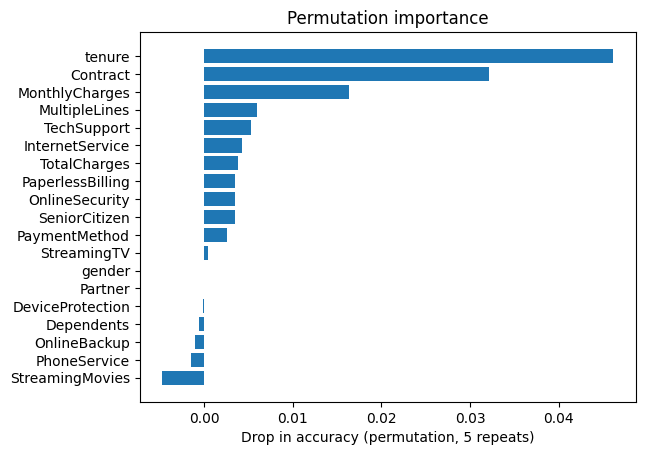

In [46]:
# ⚡ Fast track (optional) — for those who have already done ML
# n_repeats=5 keeps this under a few seconds on CPU.
perm = permutation_importance(
    hgb,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
order = perm.importances_mean.argsort()
fig, ax = plt.subplots()
ax.barh(X_test.columns[order], perm.importances_mean[order])
ax.set_xlabel("Drop in accuracy (permutation, 5 repeats)")
ax.set_title("Permutation importance")
plt.show()

## Attributions

- **Telco Customer Churn**: IBM Cognos Analytics sample (free
  use for samples); copy of the repository
  [IBM/telco-customer-churn-on-icp4d](https://github.com/IBM/telco-customer-churn-on-icp4d)
  under Apache-2.0. CSV source:
  [Telco-Customer-Churn.csv](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv).
- **Pipeline / metrics**: [MOOC scikit-learn (Inria)](https://inria.github.io/scikit-learn-mooc/),
  licence [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

## To go further at home

1. Module 1 of the scikit-learn MOOC (Inria) — *The predictive modeling
   pipeline*:
   [module overview](https://inria.github.io/scikit-learn-mooc/predictive_modeling_pipeline/predictive_modeling_module_intro.html)
2. *Deep Learning with PyTorch: A 60 Minute Blitz*:
   [tutorial](https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html)
3. d2l.ai, chapter 3 — *Linear Neural Networks*:
   [Linear Networks](https://d2l.ai/chapter_linear-networks/index.html)

## Empirical protocol — ⏱ ~10 min

The six cells below are the thread of the module (and of the oral exam).
Answer in prose, tied to *this* notebook.

## Problem

Answer in prose (not only code).

1. Which **business decision** should the model inform, and what is the **target**?
2. Which **metric** matches that decision, and why not accuracy alone?
3. How do you separate training and test **without leakage** (split unit, time, stratification)?

## Data

Answer in prose (not only code).

1. What are the variables, their types, and any notable **imbalances** or volumes?
2. Which columns must you **not** use (identifiers, leakages, target sub-flags)?
3. What do you know about **quality** (missing values, outliers, drift) and temporal or business coverage?

## Baseline

Answer in prose (not only code).

1. Which **naive baseline** (majority class, mean, seasonal) and what score does it get?
2. Why is this baseline the **honest floor**, and not a "deliberately weak" model?
3. Which score must you **beat** to justify a more complex model?

## Model

Answer in prose (not only code).

1. Which **model family** do you choose, and why (not "because it is deep")?
2. How do you train it (split, validation, hyperparameters, loss)?
3. Does the model **beat the baseline** on the chosen metric, on an uncontaminated split?

## Ablation

Answer in prose (not only code).

1. What happens if you remove a family of variables, a regulariser, or a block of the network?
2. Which choice (features, architecture, horizon, threshold) **actually changes** the score?
3. Does the gain justify the extra **complexity** relative to the baseline?

## Error analysis → Recommendation

Answer in prose (not only code).

1. Where does the model go wrong (**segments**, error types, horizon)?
2. Are these errors **costly** for the business, and what would you change in the data or the model?
3. What concrete **recommendation**: deploy, do not deploy, stay on the baseline, or collect this specific data?